# Trabajo Práctico N°1
## Tecnología Digital VI: Inteligencia Artificial
### Integrantes: Goya Bautista, Del Cuadro Federico, Doeswijk Timo.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import kagglehub

from sklearn.model_selection import train_test_split

from sklearn.preprocessing import StandardScaler

from sklearn.model_selection import KFold

from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)

from imblearn.over_sampling import RandomOverSampler

# **Parte 1: El camino de los datos**


## **1. Introducción al problema y análisis exploratorio**

El conjunto de datos **Telco Customer Churn** contiene información de **7043 clientes** de una empresa de telecomunicaciones. Incluye variables relacionadas con características demográficas, servicios contratados, tipo de contrato, método de pago, antigüedad del cliente, cargos mensuales y cargos totales. La variable objetivo es **`Churn`**, que indica si un cliente abandonó o no el servicio.

El problema de negocio consiste en **predecir qué clientes tienen mayor probabilidad de abandonar la empresa**. Poder identificar estos casos con anticipación permitiría tomar medidas de retención, como ofrecer promociones, descuentos o beneficios específicos, con el objetivo de reducir la pérdida de clientes y los costos asociados a adquirir nuevos usuarios.


In [ ]:
path = kagglehub.dataset_download("blastchar/telco-customer-churn")
df = pd.read_csv("/kaggle/input/telco-customer-churn/WA_Fn-UseC_-Telco-Customer-Churn.csv")
df.info()

Using Colab cache for faster access to the 'telco-customer-churn' dataset.
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract      

- La columna SeniorCitizen es del tipo int64 y se codifica como 0s y 1s. Quiero hacerla del tipo bool
- Las columnas Partner, Dependents, PhoneService, PaperlessBilling y Churn son del tipo object y se codifican con "Yes" y "No". Quiero hacerlas de tipo bool.

In [ ]:
# Modifico solo las de Yes/No
columnas_mod = ["Partner", "Dependents", "PhoneService", "PaperlessBilling", "Churn"]

for col in columnas_mod:
  if df[col].dtype != bool:
    df[col] = df[col].map({"Yes": True, "No": False})

# SeniorCitizen ya es 0/1, solo hace falta castear
df["SeniorCitizen"] = df["SeniorCitizen"].astype(bool)

# Chequeo cast
df[columnas_mod + ["SeniorCitizen"]].dtypes

,0
Partner,bool
Dependents,bool
PhoneService,bool
PaperlessBilling,bool
Churn,bool
SeniorCitizen,bool


**Detectamos que TotalCharges, que debería ser numérica, está almacenada como object debido a que existen 11 registros con espacios en blanco. Al analizar estos casos observamos que todos corresponden a clientes con tenure = 0, es decir, clientes que todavía no completaron su primer mes. Por este motivo, convertimos la columna a formato numérico y reemplazamos estos valores faltantes por 0.0.**

Si no se detectan estas anomalías, el modelo puede directamente fallar al entrenar por tipo incompatible, o la columna puede descartarse silenciosamente perdiendo una variable predictiva sin aviso. Si se fuerza la conversión sin revisar, esos espacios se vuelven NaN y una imputación automática (ej. con la media) les asignaría a clientes sin facturación un valor irreal, sesgando el modelo.

In [ ]:
df.loc[df['TotalCharges'] == " "]

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
488,4472-LVYGI,Female,False,True,True,0,False,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,True,Bank transfer (automatic),52.55,,False
753,3115-CZMZD,Male,False,False,True,0,True,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,False,Mailed check,20.25,,False
936,5709-LVOEQ,Female,False,True,True,0,True,No,DSL,Yes,...,Yes,No,Yes,Yes,Two year,False,Mailed check,80.85,,False
1082,4367-NUYAO,Male,False,True,True,0,True,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,False,Mailed check,25.75,,False
1340,1371-DWPAZ,Female,False,True,True,0,False,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,False,Credit card (automatic),56.05,,False
3331,7644-OMVMY,Male,False,True,True,0,True,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,False,Mailed check,19.85,,False
3826,3213-VVOLG,Male,False,True,True,0,True,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,False,Mailed check,25.35,,False
4380,2520-SGTTA,Female,False,True,True,0,True,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,False,Mailed check,20.00,,False
5218,2923-ARZLG,Male,False,True,True,0,True,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,One year,True,Mailed check,19.70,,False
6670,4075-WKNIU,Female,False,True,True,0,True,Yes,DSL,No,...,Yes,Yes,Yes,No,Two year,False,Mailed check,73.35,,False


In [ ]:
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")
df["TotalCharges"] = df["TotalCharges"].fillna(0)
df.loc[df["tenure"] == 0, ["tenure", "MonthlyCharges", "TotalCharges"]]

,tenure,MonthlyCharges,TotalCharges
488,0,52.55,0.0
753,0,20.25,0.0
936,0,80.85,0.0
1082,0,25.75,0.0
1340,0,56.05,0.0
3331,0,19.85,0.0
3826,0,25.35,0.0
4380,0,20.00,0.0
5218,0,19.70,0.0
6670,0,73.35,0.0


In [ ]:
df.info()
df.isna().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   bool   
 3   Partner           7043 non-null   bool   
 4   Dependents        7043 non-null   bool   
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   bool   
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   bool   


,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


##**Análisis exploratorio**

###Fecuencia de cada valor por feature
Resultará útil saber las proporciones de las distintas características de los usuarios que aparecen en el dataset.

In [ ]:
for columna in df.columns:
    print(f"\n--- {columna} ---")
    print(df[columna].value_counts(normalize=True) * 100)


--- customerID ---
customerID
3186-AJIEK    0.014198
7590-VHVEG    0.014198
5575-GNVDE    0.014198
8775-CEBBJ    0.014198
2823-LKABH    0.014198
                ...   
6713-OKOMC    0.014198
1452-KIOVK    0.014198
9305-CDSKC    0.014198
9237-HQITU    0.014198
7795-CFOCW    0.014198
Name: proportion, Length: 7043, dtype: float64

--- gender ---
gender
Male      50.47565
Female    49.52435
Name: proportion, dtype: float64

--- SeniorCitizen ---
SeniorCitizen
False    83.785319
True     16.214681
Name: proportion, dtype: float64

--- Partner ---
Partner
False    51.69672
True     48.30328
Name: proportion, dtype: float64

--- Dependents ---
Dependents
False    70.041176
True     29.958824
Name: proportion, dtype: float64

--- tenure ---
tenure
1     8.703677
72    5.139855
2     3.379242
3     2.839699
4     2.498935
        ...   
28    0.809314
39    0.795116
44    0.724123
36    0.709925
0     0.156183
Name: proportion, Length: 73, dtype: float64

--- PhoneService ---
PhoneService
Tru

#### **Visualización para ver cuántos abandonaron el servicio o no**

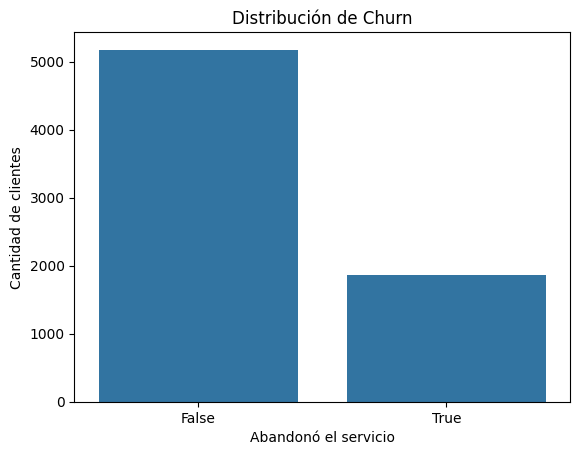

In [ ]:
sns.countplot(data=df, x="Churn")
plt.title("Distribución de Churn")
plt.xlabel("Abandonó el servicio")
plt.ylabel("Cantidad de clientes")
plt.show()

#### Tambien, quisimos comparar la cantidad de Churns dependiendo del tipo de contrato

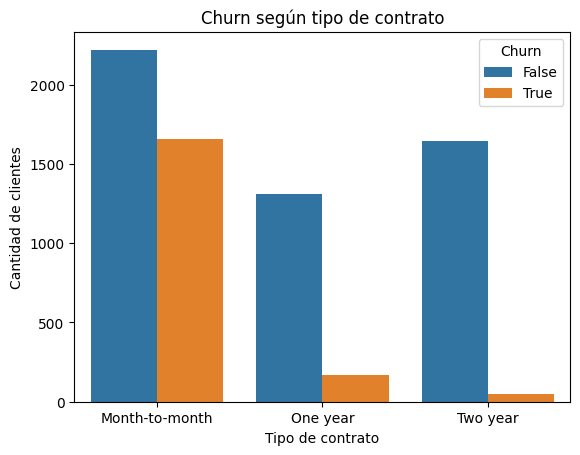

In [ ]:
sns.countplot(data=df, x="Contract", hue="Churn")
plt.title("Churn según tipo de contrato")
plt.xlabel("Tipo de contrato")
plt.ylabel("Cantidad de clientes")
plt.show()

#### Finalmente, incluimos un boxplot de tenure vs Churn, que muestra la relación de Churn con una variable numérica.

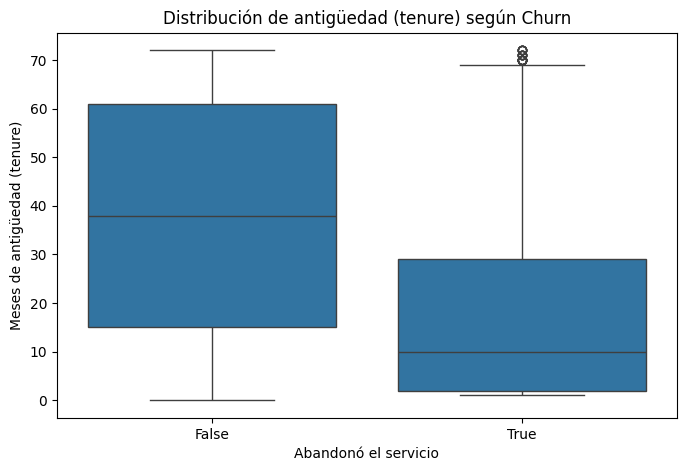

In [ ]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x="Churn", y="tenure")
plt.title("Distribución de antigüedad (tenure) según Churn")
plt.xlabel("Abandonó el servicio")
plt.ylabel("Meses de antigüedad (tenure)")
plt.show()

## **2. Preprocesamiento y prevención de Data Leakage**

Luego del primer cambio de las variables, nos quedó de la siguiente forma:

**VARIABLES BINARIAS:** SeniorCitizen, Partner, Dependents, PhoneService, PaperlessBilling y Churn.

**VARIABLES CATEGORICAS:** gender, MultipleLines, InternetService, OnlineSecurity, OnlineBackup, DeviceProtection, TechSupport, StreamingTV, StreamingMovies, Contract, PaymentMethod.

Para poder trabajar con las variables categoricas, las transformaremos con la estrategia **One Hot Encoding**

In [ ]:
categorical_cols=["gender", "MultipleLines", "InternetService", "OnlineSecurity", "OnlineBackup",
"DeviceProtection", "TechSupport", "StreamingTV", "StreamingMovies", "Contract", "PaymentMethod"]

df = pd.get_dummies(df, columns=categorical_cols, dtype=int)
df

,customerID,SeniorCitizen,Partner,Dependents,tenure,PhoneService,PaperlessBilling,MonthlyCharges,TotalCharges,Churn,...,StreamingMovies_No,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_Month-to-month,Contract_One year,Contract_Two year,PaymentMethod_Bank transfer (automatic),PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,7590-VHVEG,False,True,False,1,False,True,29.85,29.85,False,...,1,0,0,1,0,0,0,0,1,0
1,5575-GNVDE,False,False,False,34,True,False,56.95,1889.50,False,...,1,0,0,0,1,0,0,0,0,1
2,3668-QPYBK,False,False,False,2,True,True,53.85,108.15,True,...,1,0,0,1,0,0,0,0,0,1
3,7795-CFOCW,False,False,False,45,False,False,42.30,1840.75,False,...,1,0,0,0,1,0,1,0,0,0
4,9237-HQITU,False,False,False,2,True,True,70.70,151.65,True,...,1,0,0,1,0,0,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,6840-RESVB,False,True,True,24,True,True,84.80,1990.50,False,...,0,0,1,0,1,0,0,0,0,1
7039,2234-XADUH,False,True,True,72,True,True,103.20,7362.90,False,...,0,0,1,0,1,0,0,1,0,0
7040,4801-JZAZL,False,True,True,11,False,True,29.60,346.45,False,...,1,0,0,1,0,0,0,0,1,0
7041,8361-LTMKD,True,True,False,4,True,True,74.40,306.60,True,...,1,0,0,1,0,0,0,0,0,1


### **Preparación de los datos**

Antes de entrenar el modelo, separamos la variable objetivo **Churn** del resto de las variables predictoras. Además, eliminamos **customerID**, ya que funciona únicamente como identificador de cada cliente y no aporta información útil para realizar la predicción

In [ ]:
X = df.drop(columns=["Churn", "customerID"])
y = df["Churn"]

## **Train Test/Split**
Dividimos el conjunto de datos en entrenamiento (80%) y testeo (20%). El conjunto de entrenamiento será utilizado para ajustar el modelo, mientras que el conjunto de testeo permanecerá separado para evaluar su desempeño sobre datos que no fueron utilizados durante el entrenamiento.

Utilizamos stratify=y para mantener aproximadamente la misma proporción de clientes que abandonaron el servicio (Churn = 1) y los que no (Churn = 0) en ambos conjuntos.

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

## **Feature Scaling**

Aplicaremos Feature Scaling sobre las variables numericas mas altas del dataset. En este caso elegimos **tenure, MonthlyCharges y TotalCharges**

Para esto utilizamos **StandardScaler**, que estandariza cada variable utilizando su media y desviación estándar. De esta manera, evitamos que una variable tenga mayor influencia sobre el modelo únicamente por manejar valores numéricamente más grandes.

El escalador se ajusta únicamente utilizando los datos de entrenamiento **X_train**. Luego, la misma transformación aprendida se aplica sobre **X_test**

In [ ]:
scaler = StandardScaler()

numerical_cols = ["tenure", "MonthlyCharges", "TotalCharges"]
X_train[numerical_cols] = scaler.fit_transform(X_train[numerical_cols])
X_test[numerical_cols] = scaler.transform(X_test[numerical_cols])

In [ ]:
X_train[numerical_cols].describe()

,tenure,MonthlyCharges,TotalCharges
count,5.634000e+03,5.634000e+03,5.634000e+03
mean,-1.008935e-17,-2.402527e-16,2.522338e-17
std,1.000089e+00,1.000089e+00,1.000089e+00
min,-1.322329e+00,-1.544028e+00,-1.008922e+00
25%,-9.559779e-01,-9.711977e-01,-8.321009e-01
50%,-1.418632e-01,1.848336e-01,-3.968446e-01
75%,9.164859e-01,8.319124e-01,6.741944e-01
max,1.608483e+00,1.785939e+00,2.801869e+00


## **Prevención de Data Leakage**

Es importante realizar la división entre entrenamiento y testeo antes de ajustar transformaciones que utilicen información de los datos, como el escalado o una imputación basada en medias o medianas.

En nuestro caso, *StandardScaler* calcula la media y la desviación estándar utilizando únicamente **X_train**. Luego, esos mismos valores se utilizan para transformar **X_test**.

Si ajustáramos el escalador utilizando todo el dataset antes de realizar el Train/Test Split, estaríamos incorporando información del conjunto de testeo durante el entrenamiento. Este problema se conoce como **Data Leakage** y puede producir una evaluación demasiado optimista del desempeño del modelo.

## **3. Estrategia de validacion**
Se construyó un *KFold Cross Validation* de cinco *folds* (es decir, n = 5).

In [ ]:
kf = KFold(n_splits=5, random_state=42, shuffle=True)

i = 1
for train_idx, val_idx in kf.split(X_train, y_train):
    print(f"Fold {i}: {len(train_idx)} para train / {len(val_idx)} para validación")
    i += 1

Fold 1: 4507 para train / 1127 para validación
Fold 2: 4507 para train / 1127 para validación
Fold 3: 4507 para train / 1127 para validación
Fold 4: 4507 para train / 1127 para validación
Fold 5: 4508 para train / 1126 para validación


deEl método de *Cross-Validation* simula adecuadamente como se comportaría el modelo ante datos nuevos, brindando un feedback realista. En el *Holdout* tradicional, 80/20, tanto el entrenamiento como la validación del modelo se ven limitados:

1. el primero porque, al dejar algunos datos reservados para la evaluación final, el modelo no aprovecha la fuente en su completitud para ser entrenado, por lo que resulta sesgado;
2. el segundo, por ser el principal medidor de performance del modelo, va a resultar, a su vez, sesgado.

Por ejemplo, si construimos un split de train-test 80/20 con *Holdout* y, de casualidad, la minoría del dataset que efectivamente *churnea* (aprox. un 30% del total) queda casi toda dentro del set de test, el modelo va a reconocer al *churn* como caso excepcional. Por ende, al momento de correr las pruebas, va a tener poca eficacia de predicción según el perfil.

Sería conveniente usar *Stratified KFold*, ya que hay **algunas** features desbalanceadas que, pese al uso del *KFold* normal (deja al azar la distribución haciendo shuffle), pueden quedar excluídas en ciertas iteraciones de train-test, desbalanceando el *accuracy*.

## **4. Evaluación del modelo base**

Para realizar una primera evaluación del problema utilizaremos **Regresión Logistica** como modelo base de clasificación, ya que es un modelo básico para clasificación binaria que nos sirve como piso de comparación antes de probar otros modelos más complejos.
El modelo será entrenado utilizando todo el conjunto de entrenamiento **X_train** e **y_train** y luego será evaluado sobre el conjunto de testeo **X_test** e **y_test**

In [ ]:
modelo = LogisticRegression(max_iter=1000)
modelo.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

##**Predicciones sobre el conjunto de testeo**

Una vez que entrenamos el modelo, realizamos las predicciones sobre **X_test**

In [ ]:
y_pred = modelo.predict(X_test)

## **Métricas de evaluación**

Evaluaremos el desempeño del modelo utilizando **Matriz de Confusión, Accuracy, Precision, Recall y F1-Score**

In [ ]:
accuracy=accuracy_score(y_test, y_pred)
precision=precision_score(y_test, y_pred)
recall=recall_score(y_test, y_pred)
f1=f1_score(y_test, y_pred)

print(f"Accuracy: {accuracy:.2f}")
print(f"Precision: {precision:.2f}")
print(f"Recall: {recall:.2f}")
print(f"F1-Score: {f1:.2f}")

Accuracy: 0.81
Precision: 0.66
Recall: 0.56
F1-Score: 0.61


## **Matriz de confusión**

La matriz de confusión permite observar no solo cuántas predicciones fueron correctas, sino también qué tipo de errores cometió el modelo.

En nuestro problema:

- **Verdadero Negativo (TN):** predijo que el cliente no abandonaría y efectivamente no abandonó.
- **Falso Positivo (FP):** predijo que el cliente abandonaría, pero finalmente no lo hizo.
- **Falso Negativo (FN):** predijo que el cliente no abandonaría, pero sí abandonó.
- **Verdadero Positivo (TP):** predijo correctamente que el cliente abandonaría.

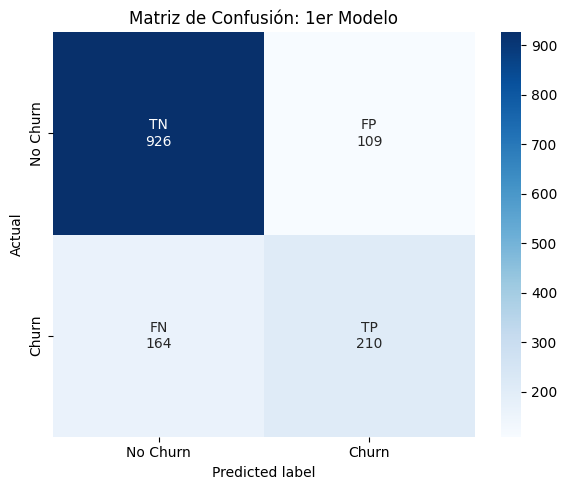

In [ ]:
cm = confusion_matrix(y_test, y_pred)

TN, FP, FN, TP = cm.ravel()

labels = [
    f"TN\n{TN}",
    f"FP\n{FP}",
    f"FN\n{FN}",
    f"TP\n{TP}"
]

labels = np.array(labels).reshape(2, 2)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=labels,
    fmt="",
    cmap="Blues",
    xticklabels=["No Churn", "Churn"],
    yticklabels=["No Churn", "Churn"]
)

plt.title("Matriz de Confusión: 1er Modelo")
plt.xlabel("Predicted label")
plt.ylabel("Actual")

plt.tight_layout()
plt.show()

##**Interpretación de los resultados**

El modelo de **Regresión Logística** obtuvo un **Accuracy de 0.81**, lo que significa que clasificó correctamente aproximadamente el 81% de los clientes del conjunto de testeo.

Sin embargo, debido al desbalance existente en la variable Churn, el Accuracy no debe analizarse de forma aislada. El modelo obtuvo una **Precision de 0.66**, un **Recall de 0.56** y un **F1-Score de 0.61**. Esto muestra que, aunque el desempeño general del modelo es bueno, su capacidad para identificar correctamente a los clientes que efectivamente abandonan el servicio es menor que lo que podría sugerir el Accuracy por sí solo.

La matriz de confusión muestra **210 Verdaderos Positivos** y **164 Falsos Negativos**, es decir, el modelo logró detectar correctamente a 210 clientes que efectivamente abandonaron el servicio, pero no logró identificar a otros 164 clientes que también hicieron Churn.

## **Modelo naive**

Para evaluar mejor el desempeño de nuestro modelo, lo comparamos con un **modelo naive** que siempre predice la clase mayoritaria.

En este dataset, la clase mayoritaria corresponde a los clientes que **no abandonan el servicio (Churn = 0)**.

Por lo tanto, este modelo naive predeciría **0** para todos los clientes del conjunto de testeo. Su Accuracy sería igual a la proporción de clientes pertenecientes a la clase mayoritaria.

In [ ]:
y_test.value_counts(normalize=True)

,proportion
Churn,
False,0.734564
True,0.265436


In [ ]:
accuracy_naive = y_test.value_counts(normalize=True).max()
print(f"Accuracy del modelo naive: {accuracy_naive:.2f}")

Accuracy del modelo naive: 0.73


## **Comparación con el modelo base**

El modelo naive obtiene un Accuracy de aproximadamente **73%**, simplemente prediciendo que ningún cliente abandonará el servicio.

Nuestro modelo de **Regresión Logística** obtuvo un Accuracy de **81%**, por lo que supera al modelo naive.

Esto demuestra por qué el Accuracy no es suficiente para evaluar este problema. Un modelo que no detecta ningún caso de churn podría obtener igualmente un Accuracy alto debido al desbalance de clases.

Por este motivo, también es importante considerar métricas como **Precision, Recall y F1-Score**, especialmente porque el objetivo del problema es poder identificar correctamente a los clientes que tienen riesgo de abandonar el servicio.

## **5. Análisis de Negocio e Impacto de las Métricas**
Para lidiar con el desbalanceo de clases, decidimos aplicar *Random Oversampling* a las clases minoritarias.

In [ ]:
ros = RandomOverSampler(random_state=42)

X_train_resampled, y_train_resampled = ros.fit_resample(X_train, y_train)

modelo = LogisticRegression(max_iter=1000)
modelo.fit(X_train_resampled, y_train_resampled)

y_pred = modelo.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print(f"Accuracy: {accuracy:.2f}")
print(f"Precision: {precision:.2f}")
print(f"Recall: {recall:.2f}")
print(f"F1-Score: {f1:.2f}")

Accuracy: 0.73
Precision: 0.50
Recall: 0.79
F1-Score: 0.61


Comparando las primeras métricas con las obtenidas ahora tras *oversamplear*, vemos:

* Accuracy: disminuye de **0.81 a 0.73**.

* Precision: disminuye de **0.66 a 0.50**.

* Recall: aumenta de **0.56 a 0.79**.

* F1-Score: se mantiene aproximadamente en **0.61**.

En el caso de negocio planteado,

1. Un Falso Positivo es, para la empresa, un cliente que el modelo predice que va a *churnear*, pero que finalmente no lo hace. Económicamente, simboliza la inversión de intentar mantener un cliente en el servicio, mediante la promoción, cuando este en realidad no planeaba dejarlo.

2. En cambio, un Falso Negativo es aquel cliente que el modelo no reconoce como potencial *churner*. Así, no se le aplica la promoción a su servicio, por lo que sus chances de abandonarlo no se ven afectadas.

3. Si el descuento es costoso para la empresa, entonces esta va a preferir aplicarlo de manera más exacta, es decir, a los clientes que verdaderamente están próximos a darse de baja. Por lo tanto, va a buscar mitigar los Falsos Positivos, es decir, no dar el descuento a los que no corresponde. Por esto, la *Precision* es la métrica a maximizar.

El caso inverso se daría si el costo de la campaña fuera muy bajo. En ese caso, la empresa podría aceptar otorgar descuentos a algunos clientes que finalmente no abandonarían el servicio, con tal de detectar la mayor cantidad posible de clientes que sí están en riesgo de fuga. Por lo tanto, sería conveniente maximizar el **Recall**, reduciendo la cantidad de Falsos Negativos.

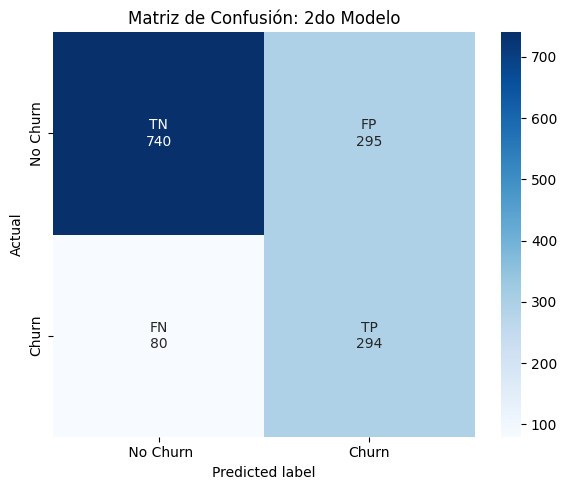

In [ ]:
cm = confusion_matrix(y_test, y_pred)

TN, FP, FN, TP = cm.ravel()

labels = [
    f"TN\n{TN}",
    f"FP\n{FP}",
    f"FN\n{FN}",
    f"TP\n{TP}"
]

labels = np.array(labels).reshape(2, 2)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=labels,
    fmt="",
    cmap="Blues",
    xticklabels=[" No Churn", "Churn"],
    yticklabels=["No Churn", "Churn"]
)

plt.title("Matriz de Confusión: 2do Modelo")
plt.xlabel("Predicted label")
plt.ylabel("Actual")

plt.tight_layout()
plt.show()

## **Comparación entre el modelo base y el modelo con Oversampling**

En el modelo base se obtuvieron **164 Falsos Negativos** y **210 Verdaderos Positivos**. En cambio, luego de aplicar Oversampling, los Falsos Negativos disminuyeron a **80** y los Verdaderos Positivos aumentaron a **294**.

Esto se refleja directamente en el aumento del **Recall**, que pasó de **0.56 a 0.79**. Por lo tanto, el segundo modelo logra detectar una mayor proporción de los clientes que efectivamente abandonan el servicio.

Sin embargo, esta mejora tiene un costo. Los Falsos Positivos aumentaron de **109 a 295**, lo que significa que una mayor cantidad de clientes que no iban a abandonar el servicio fueron clasificados como potenciales churners. Como consecuencia, la **Precision** disminuyó de **0.66 a 0.50**.

El Accuracy también disminuyó de **0.81 a 0.73**, mientras que el F1-Score se mantuvo aproximadamente en **0.61**.

Desde el punto de vista del negocio, si el descuento del 50% es muy costoso para la empresa, sería conveniente priorizar la **Precision**, ya que interesaría reducir la cantidad de Falsos Positivos y evitar ofrecer descuentos a clientes que no iban a abandonar el servicio.

En cambio, si el descuento tuviera un costo muy bajo, sería preferible priorizar el **Recall**, ya que el objetivo sería detectar la mayor cantidad posible de clientes con riesgo de abandono, aun aceptando ofrecer el beneficio a algunos clientes que finalmente no iban a darse de baja.

## **Parte II: Reformulando el problema**
Nuestra nueva variable target será **Contract_Month-to-month**, buscando predecir si un cliente tendrá un contrato de mes a mes o no. Esta feature fue transformada al utilizar **One Hot Encoding** desde la columna Contract, que puede tomar tres valores posibles: "Month-to-Month", "One year", "Two year".

Como solo nos interesa predecir si el contrato es "Month-to-Month" o no, eliminamos las features creadas para las otras dos opciones




In [ ]:
X = df.drop(columns=["Contract_Month-to-month", "Contract_One year", "Contract_Two year", "customerID"])
y = df["Contract_Month-to-month"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

modelo = LogisticRegression(max_iter=1000)
modelo.fit(X_train, y_train)

y_pred = modelo.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print(f"Accuracy: {accuracy:.2f}")
print(f"Precision: {precision:.2f}")
print(f"Recall: {recall:.2f}")
print(f"F1-Score: {f1:.2f}")

Accuracy: 0.86
Precision: 0.86
Recall: 0.89
F1-Score: 0.87


## **Interpretación de los resultados**

El modelo obtuvo un **Accuracy de 0.86**, una **Precision de 0.86**, un **Recall de 0.89** y un **F1-Score de 0.87**.

En conjunto, estas métricas muestran que `Contract_Month-to-month` es un objetivo bastante predecible a partir de las demás características del dataset. El buen desempeño no depende únicamente del Accuracy, ya que Precision, Recall y F1-Score también presentan valores altos y relativamente equilibrados.

El **Recall de 0.89** indica que, entre los clientes que realmente poseen un contrato mes a mes, el modelo logra identificar correctamente a aproximadamente el **89%**. Es decir, deja sin detectar solo una proporción relativamente pequeña de estos casos.

Por otro lado, una **Precision de 0.86** indica que, cuando el modelo predice que un cliente tiene un contrato mes a mes, esa predicción es correcta aproximadamente en el **86%** de los casos. Por lo tanto, el modelo no solo logra encontrar a la mayoría de los clientes con este tipo de contrato, sino que además genera relativamente pocas clasificaciones positivas incorrectas.

Esto sugiere que existen relaciones importantes entre el tipo de contrato y otras características de los clientes presentes en el dataset. Por ejemplo, variables relacionadas con la antigüedad, los servicios contratados, el método de pago o los cargos podrían aportar información útil para distinguir a los clientes con contratos mes a mes de aquellos con contratos de mayor duración.

Por lo tanto, podemos considerar que el nuevo objetivo es **altamente predecible dentro de este conjunto de datos**, aunque estos resultados no permiten afirmar por sí solos cuáles son las variables más importantes para realizar la predicción.

## Conclusiones

- El desbalanceo de clases condiciona la estrategia de modelado y evaluación
- TotalCharges es un ejemplo de cómo una anomalía que no se detecta facilmente (los vacios no se reconocen como NaN) puede degradar un modelo si no se detecta a tiempo
- El orden de split y luego imputación/escalado es importante para evitar Data Leakage
- La elección Precision vs. Recall depende del costo económico real del descuento, no solo de las métricas aisladas
- Contract_Month-to-month resultó más predecible que Churn con el modelo utilizado, ya que obtuvo métricas de testeo superiores.

## Mejoras

- Probar modelos no lineales
- Ajustar el umbral de decisión en vez de solo cambiar el método de balanceo
- Agregar Feature Engineering adicional
- Evaluar importancia de variables para entender qué atributos pesan más en la predicción y depurar el modelo de variables poco informativas
- Aplicar Stratified K-Fold